In [4]:
!pip install -U langchain langgraph langchain-ollama

  Using cached langchain-1.4.0-py3-none-any.whl (161 kB)
  Using cached langchain_ollama-1.1.0-py3-none-any.whl (31 kB)
  Attempting uninstall: langchain-ollama
    Found existing installation: langchain-ollama 0.3.3
    Uninstalling langchain-ollama-0.3.3:
      Successfully uninstalled langchain-ollama-0.3.3
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.27
    Uninstalling langchain-0.3.27:
      Successfully uninstalled langchain-0.3.27



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:

from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.messages import RemoveMessage

In [6]:

load_dotenv()
from langchain_ollama import ChatOllama
model = ChatOllama(
    model="qwen3:4b",
    temperature=0,
    think=False
)

In [7]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [8]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [9]:

builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [10]:

graph = builder.compile(checkpointer=InMemorySaver())

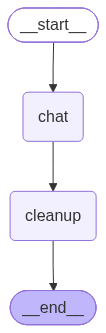

In [11]:

graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

In [13]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

KeyboardInterrupt: 

In [ ]:

snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))